# Chapter 9a — Introduction to CUDA C (a slower on-ramp)

> Companion to **Chapter 9 — Hello, GPU**.  Distilled from *CUDA by Example* (Sanders & Kandrot), chapters 2–3.

Chapter 9 threw you straight into a working GELU kernel. That's the fast path. This companion **slows the pace right down** and rebuilds the same foundation one tiny program at a time — the way *CUDA by Example* introduces it. If anything in Ch9 felt like it moved too fast (the five-step dance, device pointers, `<<<...>>>`), this is the chapter that makes it click.

We'll write **three** of the smallest possible CUDA programs:

1. A kernel that does **nothing** — just to see `__global__` and `<<<1,1>>>` in isolation.
2. A kernel that **adds two integers** — to learn how data crosses the host↔device boundary.
3. A program that **interrogates your GPU** — printing the real specs of your RTX 4080 SUPER, and connecting them back to the `block_size`, warp, and bandwidth numbers from Ch9.

### Learning objectives

By the end you will:

- Write and launch the minimal `__global__` kernel and explain what `<<<1, 1>>>` means.
- Pass parameters into a kernel and get a result back, understanding **why** the output must be a `cudaMalloc`'d device pointer.
- Query the device with `cudaGetDeviceProperties` and read off the numbers that explain Ch9's tuning advice (warp size, max threads/block, SM count, memory bus width).


## 1. The one picture that explains all of CUDA: Host vs Device

Every CUDA program is a conversation between **two separate machines** that share no memory:

- the **host** — your CPU and its RAM, where `main()` runs;
- the **device** — your GPU and its VRAM, where kernels run.

A pointer from one is meaningless to the other. The CUDA runtime gives you exactly the tools to move data and control across the **PCIe bus** between them. Run the cell below to draw the model — this single diagram is the mental model behind the "five-step dance" from Ch9.


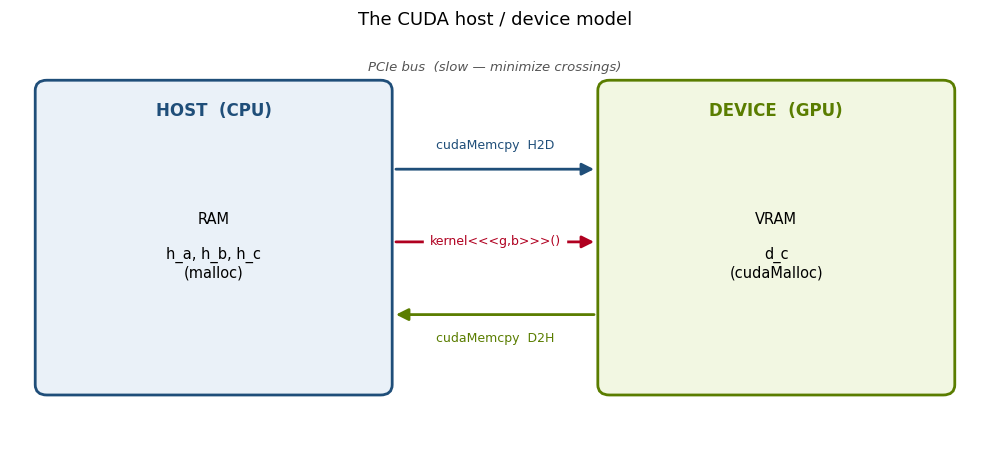

In [1]:
# Run me: a live diagram of the host/device model (matplotlib, no GPU needed).
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.set_xlim(0, 10); ax.set_ylim(0, 5); ax.axis("off")

def box(x, y, w, h, label, color, fc):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.04,rounding_size=0.12",
                                linewidth=2, edgecolor=color, facecolor=fc))
    ax.text(x + w/2, y + h - 0.32, label, ha="center", va="center",
            fontsize=12, fontweight="bold", color=color)

# Host (CPU) on the left, Device (GPU) on the right
box(0.3, 0.8, 3.6, 3.6, "HOST  (CPU)", "#1f4e79", "#eaf1f8")
box(6.1, 0.8, 3.6, 3.6, "DEVICE  (GPU)", "#5a7d00", "#f2f7e2")
ax.text(2.1, 2.5, "RAM\n\nh_a, h_b, h_c\n(malloc)", ha="center", va="center", fontsize=10.5)
ax.text(7.9, 2.5, "VRAM\n\nd_c\n(cudaMalloc)", ha="center", va="center", fontsize=10.5)

# PCIe channel between them
ax.text(5.0, 4.55, "PCIe bus  (slow — minimize crossings)", ha="center", fontsize=9.5, style="italic", color="#555")

def arrow(x0, y0, x1, y1, text, color, dy=0.0):
    ax.add_patch(FancyArrowPatch((x0, y0), (x1, y1), arrowstyle="-|>", mutation_scale=18,
                                 linewidth=2, color=color))
    ax.text((x0+x1)/2, (y0+y1)/2 + dy, text, ha="center", va="center", fontsize=9,
            color=color, backgroundcolor="white")

arrow(3.95, 3.4, 6.05, 3.4, "cudaMemcpy  H2D", "#1f4e79", dy=0.28)   # host -> device
arrow(6.05, 1.7, 3.95, 1.7, "cudaMemcpy  D2H", "#5a7d00", dy=-0.28)  # device -> host
arrow(3.95, 2.55, 6.05, 2.55, "kernel<<<g,b>>>()", "#b00020", dy=0.0)  # launch

ax.set_title("The CUDA host / device model", fontsize=13)
plt.tight_layout(); plt.show()

Read the arrows as the lifecycle of every CUDA program:

1. `cudaMalloc` a buffer in **VRAM** (the device side).
2. `cudaMemcpy(..., HostToDevice)` your input across the PCIe bus.
3. Launch the kernel with `kernel<<<grid, block>>>(...)` — the red arrow.
4. `cudaMemcpy(..., DeviceToHost)` the result back.
5. `cudaFree` the device buffer.

The blue/green `cudaMemcpy` arrows are the **expensive** part. Keeping data resident in VRAM across many kernels (instead of shuttling it back and forth) is most of what "optimizing" a GPU program means.


## 2. Program 1 — A kernel that does nothing

The smallest legal CUDA program. We mark a function `__global__` (runs on the device, called from the host) and launch a single thread with `<<<1, 1>>>`.

In [2]:
!mkdir -p course/ch09a_build


In [3]:
%%writefile course/ch09a_build/first_kernel.cu
#include <stdio.h>
#include <cuda_runtime.h>

// A kernel: runs on the GPU. Empty body — it does nothing (yet).
__global__ void kernel(void) {
}

int main(void) {
    // <<<1, 1>>> = 1 block of 1 thread = a single GPU thread runs kernel().
    kernel<<<1, 1>>>();
    cudaDeviceSynchronize();          // wait for the (instant) kernel to finish
    printf("Kernel launched and completed on the GPU. (It did nothing — by design.)\n");
    return 0;
}


Overwriting course/ch09a_build/first_kernel.cu


In [4]:
!nvcc -O2 -o course/ch09a_build/first_kernel course/ch09a_build/first_kernel.cu && ./course/ch09a_build/first_kernel


Kernel launched and completed on the GPU. (It did nothing — by design.)


Two things are happening that ordinary C can't do:

- `__global__` tells `nvcc` to compile `kernel` for the **GPU's** instruction set, not the CPU's.
- `kernel<<<1, 1>>>()` is the **launch syntax** — the `<<<grid, block>>>` angle brackets are a CUDA extension to C. `nvcc` splits the file: host code (`main`) is handed to your normal C compiler, device code (`kernel`) to the GPU compiler. That's why the file must be `.cu` and built with `nvcc`.

`<<<1, 1>>>` is the most boring launch geometry possible: one block, one thread. In Ch9 you already used `<<<grid_size, block_size>>>` to launch *millions* of threads. Same syntax — bigger numbers.


## 3. Program 2 — Passing parameters across the boundary

Now make the kernel actually compute something: add two integers. The subtlety is **getting the answer back**. A kernel returns `void` — it can't `return` a value to the host. It must **write into device memory**, which the host then copies back.


In [5]:
%%writefile course/ch09a_build/passing_parameters.cu
#include <stdio.h>
#include <cuda_runtime.h>

// a and b are passed BY VALUE (the host copies them into the launch).
// c is a DEVICE pointer — the kernel writes the result into VRAM.
__global__ void add(int a, int b, int* c) {
    *c = a + b;
}

int main(void) {
    int  c;            // host copy of the result
    int* dev_c;        // device pointer for the result

    cudaMalloc((void**)&dev_c, sizeof(int));         // 1. allocate result slot in VRAM

    add<<<1, 1>>>(2, 7, dev_c);                       // 2. launch: 2 and 7 go by value

    cudaMemcpy(&c, dev_c, sizeof(int),                // 3. copy result device -> host
               cudaMemcpyDeviceToHost);

    printf("2 + 7 = %d\n", c);                         // 4. now it's safe to read on the host

    cudaFree(dev_c);                                  // 5. free VRAM
    return 0;
}


Overwriting course/ch09a_build/passing_parameters.cu


In [6]:
!nvcc -O2 -o course/ch09a_build/passing_parameters course/ch09a_build/passing_parameters.cu && ./course/ch09a_build/passing_parameters


2 + 7 = 9


**The single most important rule in this chapter:** you cannot dereference a device pointer on the host.

```c
printf("%d\n", *dev_c);   // WRONG — segfault. dev_c points into VRAM; the CPU can't read it.
```

`dev_c` is a perfectly valid number on the host (it's just an address), but that address only means something *to the GPU*. To see the value you must `cudaMemcpy` it into a host variable (`c`) first. This is the same rule Ch9's pitfall #3 warned about — here it is in its simplest possible form.

Notice the asymmetry: `a` and `b` (plain `int`s) cross into the kernel **by value** for free, but anything the kernel needs to *write* must live in device memory you allocated.


## 4. Program 3 — Interrogating your GPU

CUDA can tell you everything about the hardware it's running on via `cudaGetDeviceProperties`, which fills a `cudaDeviceProp` struct. This isn't trivia — these numbers **are** the constraints behind Ch9's tuning rules (why `block_size` ≤ 1024, why it must be a multiple of 32, what bandwidth to expect).

In [7]:
%%writefile course/ch09a_build/device_query.cu
#include <stdio.h>
#include <cuda_runtime.h>

int main(void) {
    int count;
    cudaGetDeviceCount(&count);
    printf("CUDA-capable devices found: %d\n\n", count);

    for (int i = 0; i < count; i++) {
        cudaDeviceProp p;
        cudaGetDeviceProperties(&p, i);
        printf("Device %d: %s\n", i, p.name);
        printf("  Compute capability ....... %d.%d\n", p.major, p.minor);
        printf("  Global memory (VRAM) ..... %.1f GB\n", p.totalGlobalMem / (1024.0*1024.0*1024.0));
        printf("  Multiprocessors (SMs) .... %d\n", p.multiProcessorCount);
        printf("  Warp size ................ %d threads\n", p.warpSize);
        printf("  Max threads / block ...... %d\n", p.maxThreadsPerBlock);
        printf("  Max block dim (x,y,z) .... (%d, %d, %d)\n",
               p.maxThreadsDim[0], p.maxThreadsDim[1], p.maxThreadsDim[2]);
        printf("  Max grid dim  (x,y,z) .... (%d, %d, %d)\n",
               p.maxGridSize[0], p.maxGridSize[1], p.maxGridSize[2]);
        printf("  Shared mem / block ....... %.0f KB\n", p.sharedMemPerBlock / 1024.0);
        printf("  Registers / block ........ %d\n", p.regsPerBlock);
        printf("  GPU clock ................ %.2f GHz\n", p.clockRate * 1e-6);
        printf("  Memory clock ............. %.2f GHz\n", p.memoryClockRate * 1e-6);
        printf("  Memory bus width ......... %d bits\n", p.memoryBusWidth);
    }
    return 0;
}


Overwriting course/ch09a_build/device_query.cu


In [8]:
!nvcc -O2 -o course/ch09a_build/device_query course/ch09a_build/device_query.cu && ./course/ch09a_build/device_query


CUDA-capable devices found: 1

Device 0: NVIDIA GeForce RTX 4080 SUPER
  Compute capability ....... 8.9
  Global memory (VRAM) ..... 15.6 GB
  Multiprocessors (SMs) .... 80
  Warp size ................ 32 threads
  Max threads / block ...... 1024
  Max block dim (x,y,z) .... (1024, 1024, 64)
  Max grid dim  (x,y,z) .... (2147483647, 65535, 65535)
  Shared mem / block ....... 48 KB
  Registers / block ........ 65536
  GPU clock ................ 2.61 GHz
  Memory clock ............. 11.50 GHz
  Memory bus width ......... 256 bits


Now Ch9's rules of thumb stop being magic. Look at the output and connect the dots:

- **Warp size = 32** → why `block_size` should be a multiple of 32 (anything else leaves lanes of a warp idle).
- **Max threads / block = 1024** → why `block_size` above 1024 is illegal.
- **Multiprocessors (SMs)** → how many blocks can truly run at once; you want `grid_size` ≫ SM count to keep them all fed.
- **Memory bus width & memory clock** → these set the **theoretical bandwidth** that capped GELU at ~660 GB/s in Ch9. You'll compute that number yourself in the exercise.


## 5. The Translation Bridge — Ch9 in slow motion

| Ch9 (the GELU port) | Ch9a (the same idea, minimal) |
|---|---|
| `gelu_forward_kernel1<<<grid, block>>>(d_out, d_inp, N)` | `add<<<1, 1>>>(2, 7, dev_c)` |
| `cudaMalloc(&d_out, N*sizeof(float))` | `cudaMalloc((void**)&dev_c, sizeof(int))` |
| `cudaMemcpy(h_out, d_out, ..., DeviceToHost)` | `cudaMemcpy(&c, dev_c, ..., DeviceToHost)` |
| millions of threads, `if (i < N)` guard | one thread, no guard needed |
| tuned `block_size` from rules of thumb | the **device-query numbers** those rules come from |

Same five steps, same syntax. Ch9 just used big arrays and big launch geometry; here each idea stands alone.


## 6. Common Pitfalls

1. **Dereferencing a device pointer on the host** (`*dev_c` in host code) — segfault. Always `cudaMemcpy` to a host variable first.
2. **Forgetting `(void**)` on `cudaMalloc`'s first argument.** `cudaMalloc` takes the *address of your pointer* so it can fill it in: `cudaMalloc((void**)&dev_c, bytes)`.
3. **Building a `.cu` file with `gcc`/`cc`.** The `<<<>>>` syntax and `__global__` are CUDA extensions — only `nvcc` understands them.
4. **Reading `cudaDeviceProp` fields with the wrong units.** `clockRate`/`memoryClockRate` are in **kHz**; `totalGlobalMem`/`sharedMemPerBlock` are in **bytes**. Convert before printing.


## 7. TODO Exercise — compute your GPU's theoretical memory bandwidth

In Ch9 the GELU benchmark topped out around **660 GB/s** and the prose claimed the card's peak is "700–800 GB/s". Now prove it from first principles using the device-query numbers.

Theoretical peak bandwidth (for GDDR memory, which transfers on both clock edges) is:

```
bandwidth (bytes/s) = 2  ×  memory_clock_Hz  ×  (bus_width_bits / 8)
```

Fill in the one line marked `TODO` and run it. Your answer should land in the ~700–800 GB/s range — and the ~660 GB/s you measured in Ch9 is that peak minus real-world overhead.


In [11]:
%%writefile course/ch09a_build/exercise_bandwidth.cu
#include <stdio.h>
#include <cuda_runtime.h>

int main(void) {
    cudaDeviceProp p;
    cudaGetDeviceProperties(&p, 0);

    double mem_clock_hz = (double)p.memoryClockRate * 1000.0;  // kHz -> Hz
    double bus_bytes    = (double)p.memoryBusWidth / 8.0;      // bits -> bytes

    // TODO: combine mem_clock_hz and bus_bytes (and the factor of 2 for GDDR)
    //       into bytes per second, then convert to GB/s (divide by 1e9).
    double bandwidth_gb_s = 2 * mem_clock_hz * bus_bytes / 1e9;   // <-- replace 0.0

    printf("%s: theoretical peak memory bandwidth = %.1f GB/s\n", p.name, bandwidth_gb_s);
    printf("(Ch9 measured ~660 GB/s on GELU; that's %.0f%% of peak.)\n",
           bandwidth_gb_s > 0 ? 100.0 * 660.0 / bandwidth_gb_s : 0.0);
    return 0;
}


Overwriting course/ch09a_build/exercise_bandwidth.cu


In [12]:
!nvcc -O2 -o course/ch09a_build/exercise_bandwidth course/ch09a_build/exercise_bandwidth.cu && ./course/ch09a_build/exercise_bandwidth


NVIDIA GeForce RTX 4080 SUPER: theoretical peak memory bandwidth = 736.1 GB/s
(Ch9 measured ~660 GB/s on GELU; that's 90% of peak.)


### Solution

In [ ]:
%%writefile course/ch09a_build/exercise_bandwidth_sol.cu
#include <stdio.h>
#include <cuda_runtime.h>

int main(void) {
    cudaDeviceProp p;
    cudaGetDeviceProperties(&p, 0);

    double mem_clock_hz = (double)p.memoryClockRate * 1000.0;  // kHz -> Hz
    double bus_bytes    = (double)p.memoryBusWidth / 8.0;      // bits -> bytes

    double bandwidth_gb_s = 2.0 * mem_clock_hz * bus_bytes / 1e9;

    printf("%s: theoretical peak memory bandwidth = %.1f GB/s\n", p.name, bandwidth_gb_s);
    printf("(Ch9 measured ~660 GB/s on GELU; that's %.0f%% of peak.)\n",
           bandwidth_gb_s > 0 ? 100.0 * 660.0 / bandwidth_gb_s : 0.0);
    return 0;
}


In [ ]:
!nvcc -O2 -o course/ch09a_build/exercise_bandwidth_sol course/ch09a_build/exercise_bandwidth_sol.cu && ./course/ch09a_build/exercise_bandwidth_sol


## Recap

You rebuilt the CUDA foundation from the ground up:

- A kernel is a `__global__` function compiled for the GPU and launched with `<<<grid, block>>>`. The smallest launch is `<<<1, 1>>>`.
- The host and device have **separate memory**. Parameters cross *into* a kernel by value; results must be written to a `cudaMalloc`'d **device pointer** and `cudaMemcpy`'d back. Never dereference a device pointer on the host.
- `cudaGetDeviceProperties` reports the hardware limits (warp size, max threads/block, SM count, memory bus width) that **explain** Ch9's `block_size` and bandwidth advice.

### What's next

**Chapter 9b — Parallel Programming in CUDA C.** We stop launching a single thread and start launching *many*: vector addition spread across a grid of blocks, and your first **2D** grid via the Julia-set fractal — where the grid/block/thread hierarchy from Ch9's Figure 5.2 finally pays off.
